# Instructor Effectiveness Analysis

This project looks at how effective instructors are by using things like student results, their participation, and feedback from learners. The goal is to give each instructor an effectiveness score, group them into different effectiveness levels, and then use machine learning to predict which level an instructor belongs to.


In [ ]:
import pandas as pd

## 1. Load the data

In [ ]:
df = pd.read_excel("instructor_effectiveness_dataset_2000_rows.xlsx")

df = pd.read_excel(r"C:\Users\Vedic Nataraja\OneDrive\Documents\Accredian_Data_Science_Assignment\Accredian_Data_Science_Assignment\instructor_effectiveness_dataset_2000_rows.xlsx")

In [ ]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


df.shape

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   str    
 1   instructor_id               2000 non-null   str    
 2   course_id                   2000 non-null   str    
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), str(3)
memory usage: 187.6 KB


In [ ]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [ ]:
df["course_id"].nunique()

25

In [ ]:
df[[
    "completion_rate",
    "dropout_rate",
    "assignment_submission_rate",
    "forum_activity_rate",
    "feedback_response_rate"
]].agg(["min", "max"])

,completion_rate,dropout_rate,assignment_submission_rate,forum_activity_rate,feedback_response_rate
min,0.30,0.02,0.251111,0.000000,0.259935
max,0.98,0.70,1.000000,0.641111,1.000000


In [ ]:
df["avg_quiz_score"].agg(["min", "max"])

min     40.386725
max    100.000000
Name: avg_quiz_score, dtype: float64

In [ ]:
df["avg_feedback_score"].agg(["min", "max"])

min    2.639915
max    5.000000
Name: avg_feedback_score, dtype: float64

## 2. Observations

The dataset contains 2000 batches, 120 instructors, and 25 courses.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

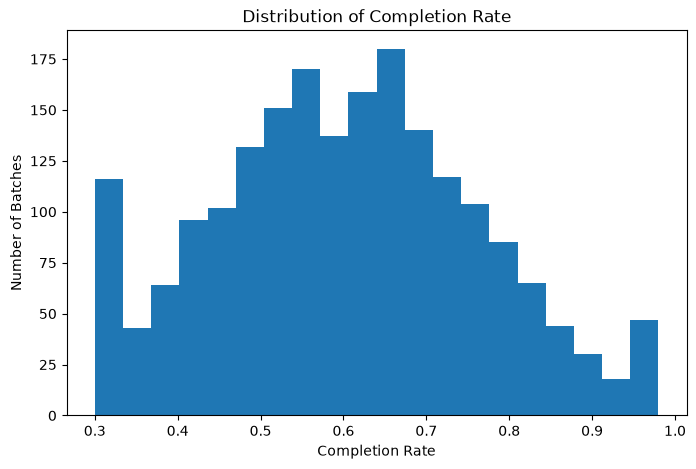

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["completion_rate"], bins=20)
plt.title("Distribution of Completion Rate")
plt.xlabel("Completion Rate")
plt.ylabel("Number of Batches")
plt.show()

**Observation** - More batches = higher completion rate, Less batches = low completion rate

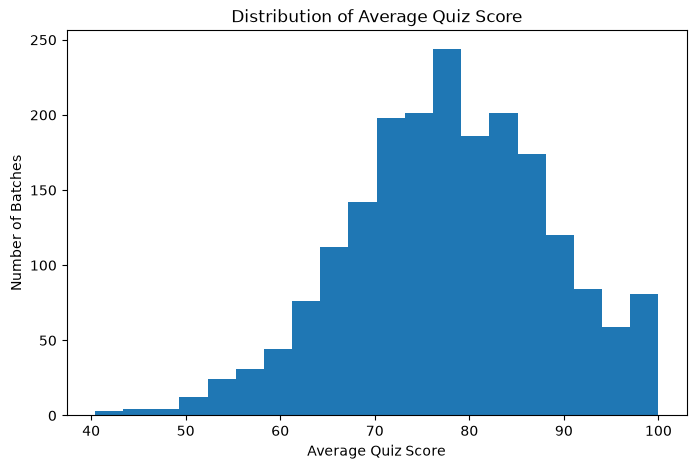

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["avg_quiz_score"], bins=20)
plt.title("Distribution of Average Quiz Score")
plt.xlabel("Average Quiz Score")
plt.ylabel("Number of Batches")
plt.show()

**Observation** - More batches = higher average quiz score, low batches = lower average quiz score

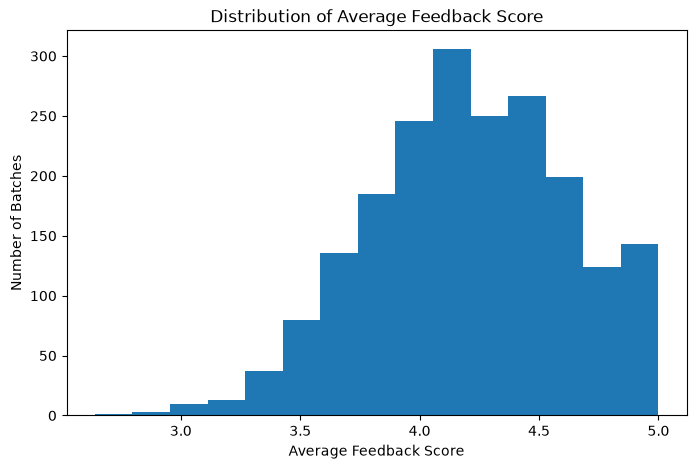

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["avg_feedback_score"], bins=15)
plt.title("Distribution of Average Feedback Score")
plt.xlabel("Average Feedback Score")
plt.ylabel("Number of Batches")
plt.show()

**Observation** - Low batches = low feedback scores, high batches = high feedback score

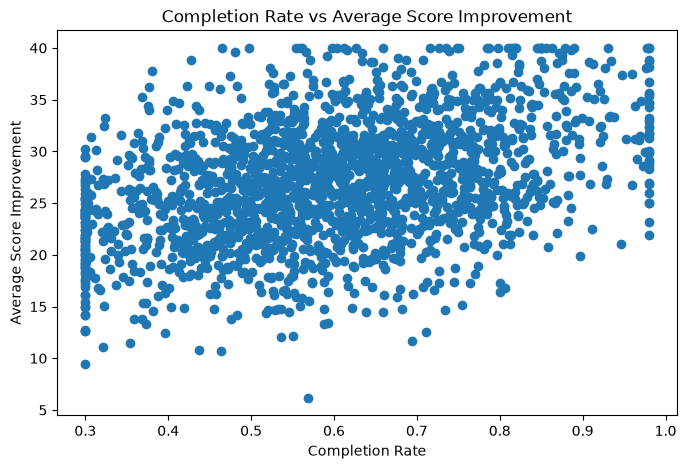

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["completion_rate"], df["avg_score_improvement"])
plt.title("Completion Rate vs Average Score Improvement")
plt.xlabel("Completion Rate")
plt.ylabel("Average Score Improvement")
plt.show()

**Observation** - We can see that it has dense middle so we cant tell completion rate is related to score improvement from this graph alone.

In [ ]:
df["completion_rate"].corr(df["avg_score_improvement"])

np.float64(0.4041609366501502)

**Observation** - Batches with higher completion rates have better score improvements, but completion rate is not enough to decide


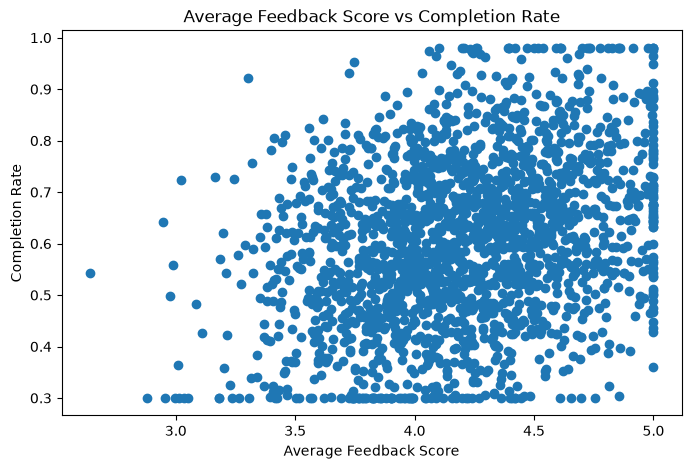

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["avg_feedback_score"], df["completion_rate"])
plt.title("Average Feedback Score vs Completion Rate")
plt.xlabel("Average Feedback Score")
plt.ylabel("Completion Rate")
plt.show()

In [ ]:
df["avg_feedback_score"].corr(df["completion_rate"])

np.float64(0.3153937332517347)

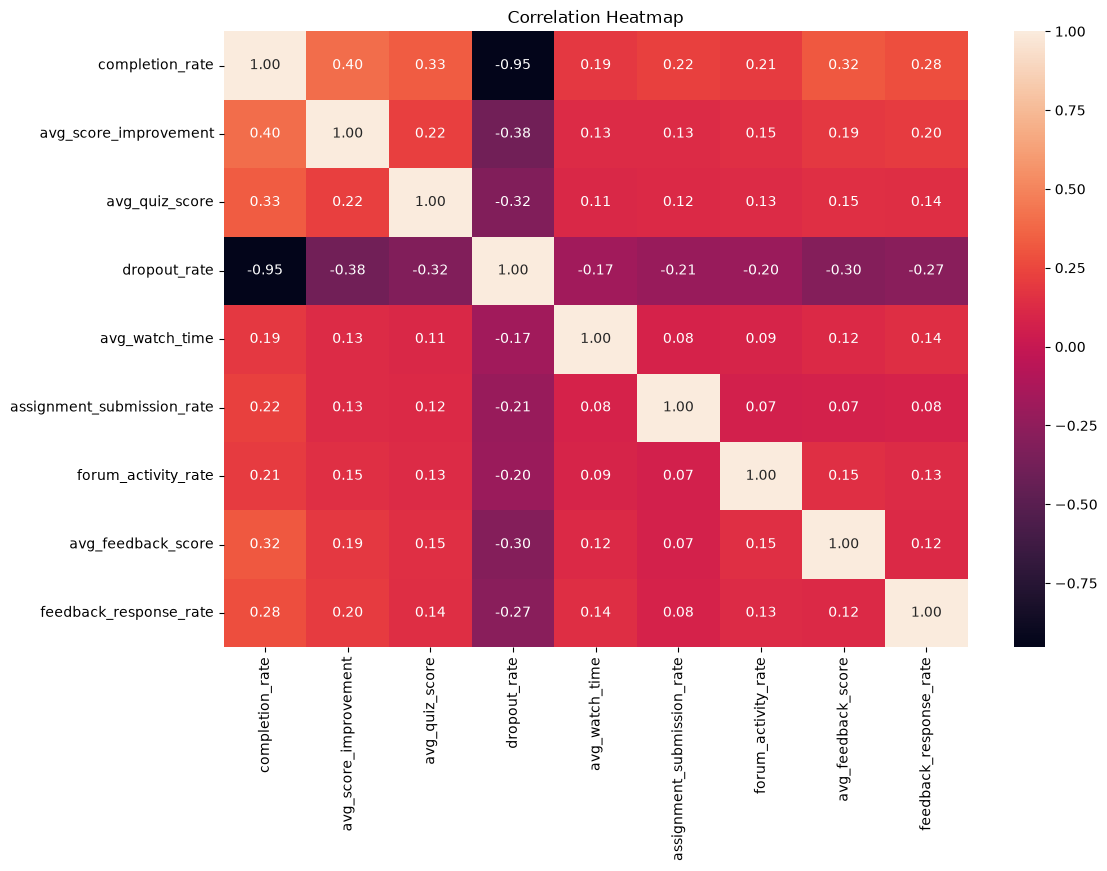

In [ ]:
plt.figure(figsize=(12, 8))
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Observation** - From aboveheat map we can see that Completion rate ~ Dropout rate (-0.95), Completion rate ~ Score improvement(0.40)

In [ ]:
print(df.dtypes)

batch_id                          str
instructor_id                     str
course_id                         str
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object


In [ ]:
print(df.columns.tolist())

['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']


## 3. Instructor-level data

The batch-level data is grouped by instructor so that each instructor has one average value for each performance measure.

In [ ]:
instructor_data = df.groupby("instructor_id")[[
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]].mean()

In [ ]:
instructor_data.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
instructor_id,,,,,,,,,
I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858
I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338
I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132
I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460
I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197


In [ ]:
instructor_data.shape

(120, 9)

## 4. Create scores

The variables are converted to a 0 to 1 scale so they can be combined into one effectiveness score. For dropout rate, a lower value is better, so its score is reversed.

In [ ]:
instructor_data["completion_score"] = (
    instructor_data["completion_rate"] - instructor_data["completion_rate"].min()
) / (
    instructor_data["completion_rate"].max() - instructor_data["completion_rate"].min()
)

In [ ]:
instructor_data["completion_score"].head()

instructor_id
I_001    0.367386
I_002    0.665425
I_003    0.725311
I_004    0.231012
I_005    0.870836
Name: completion_score, dtype: float64

In [ ]:
minimum = instructor_data["dropout_rate"].min()
maximum = instructor_data["dropout_rate"].max()

instructor_data["dropout_score"] = 1 - (
    (instructor_data["dropout_rate"] - minimum) / (maximum - minimum)
)

In [ ]:
instructor_data["dropout_score"].head()

instructor_id
I_001    0.325137
I_002    0.700104
I_003    0.720861
I_004    0.196452
I_005    0.870403
Name: dropout_score, dtype: float64

In [ ]:
minimum = instructor_data["avg_feedback_score"].min()
maximum = instructor_data["avg_feedback_score"].max()

instructor_data["feedback_score"] = (
    instructor_data["avg_feedback_score"] - minimum
) / (maximum - minimum)

In [ ]:
instructor_data["feedback_score"].head()

instructor_id
I_001    0.533079
I_002    0.670940
I_003    0.788738
I_004    0.377529
I_005    0.516321
Name: feedback_score, dtype: float64

In [ ]:
minimum = instructor_data["feedback_response_rate"].min()
maximum = instructor_data["feedback_response_rate"].max()

instructor_data["response_score"] = (
    instructor_data["feedback_response_rate"] - minimum
) / (maximum - minimum)

In [ ]:
instructor_data["response_score"].head()

instructor_id
I_001    0.348378
I_002    0.644331
I_003    0.736259
I_004    0.436363
I_005    0.643863
Name: response_score, dtype: float64

In [ ]:
print(instructor_data.columns.tolist())

['completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate', 'completion_score', 'dropout_score', 'feedback_score', 'response_score']


## 5. Effectiveness score

In [ ]:
def normalize_score(series):
    min_val, max_val = series.min(), series.max()
    if max_val == min_val:
        return pd.Series(50, index=series.index)
    return (series - min_val) / (max_val - min_val) * 100

instructor_data["score_improvement_score"] = normalize_score(instructor_data["avg_score_improvement"])
instructor_data["quiz_score"] = normalize_score(instructor_data["avg_quiz_score"])
instructor_data["watch_time_score"] = normalize_score(instructor_data["avg_watch_time"])
instructor_data["assignment_score"] = normalize_score(instructor_data["assignment_submission_rate"])
instructor_data["forum_score"] = normalize_score(instructor_data["forum_activity_rate"])

In [ ]:
instructor_data["effectiveness_score"] = (
    instructor_data["completion_score"] +
    instructor_data["score_improvement_score"] +
    instructor_data["quiz_score"] +
    instructor_data["dropout_score"] +
    instructor_data["watch_time_score"] +
    instructor_data["assignment_score"] +
    instructor_data["forum_score"] +
    instructor_data["feedback_score"] +
    instructor_data["response_score"]
) / 9

In [ ]:
instructor_data["effectiveness_score"] = instructor_data["effectiveness_score"] * 100

In [ ]:
instructor_data["effectiveness_score"].head(10)

instructor_id
I_001    2785.875417
I_002    3866.383730
I_003    3815.902542
I_004    2617.817350
I_005    4776.771400
I_006    1630.991236
I_007    3804.139902
I_008    3302.285496
I_009    2669.799635
I_010    5304.430802
Name: effectiveness_score, dtype: float64

## 6. Effectiveness categories

Instructors are grouped into three categories using their effectiveness score.


In [ ]:
def category(score):
    if score < 2500:
        return "Low"
    elif score < 4000:
        return "Medium"
    else:
        return "High"

instructor_data["effectiveness_category"] = instructor_data["effectiveness_score"].apply(category)

In [ ]:
instructor_data[["effectiveness_score", "effectiveness_category"]].head(10)

,effectiveness_score,effectiveness_category
instructor_id,,
I_001,2785.875417,Medium
I_002,3866.383730,Medium
I_003,3815.902542,Medium
I_004,2617.817350,Medium
I_005,4776.771400,High
I_006,1630.991236,Low
I_007,3804.139902,Medium
I_008,3302.285496,Medium
I_009,2669.799635,Medium


In [ ]:
instructor_data["effectiveness_category"].value_counts()

effectiveness_category
Medium    77
Low       32
High      11
Name: count, dtype: int64

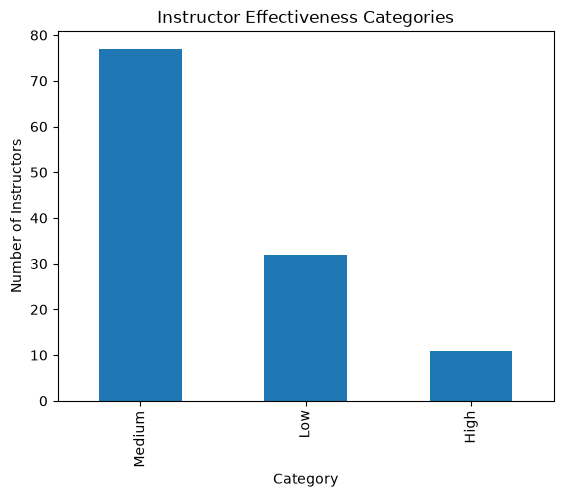

In [ ]:
instructor_data["effectiveness_category"].value_counts().plot(kind="bar")

plt.title("Instructor Effectiveness Categories")
plt.xlabel("Category")
plt.ylabel("Number of Instructors")
plt.show()

**Observation** - Most Instructors fall into Medium Category, followed by Low Category and only some instructors in High category.

In [ ]:
print(pd.crosstab(instructor_data["effectiveness_category"], 
                  instructor_data["effectiveness_score"]))

effectiveness_score     528.811077   656.415776   987.797348   1204.743182  \
effectiveness_category                                                       
High                              0            0            0            0   
Low                               1            1            1            1   
Medium                            0            0            0            0   

effectiveness_score     1477.927916  1505.385615  1593.104272  1615.569877  \
effectiveness_category                                                       
High                              0            0            0            0   
Low                               1            1            1            1   
Medium                            0            0            0            0   

effectiveness_score     1630.991236  1667.620929  ...  4046.487616  \
effectiveness_category                            ...                
High                              0            0  ...            1   
Low     

## 7. Machine learning model

In [ ]:
instructor_data[[
    "completion_score",
    "score_improvement_score",
    "quiz_score",
    "dropout_score",
    "watch_time_score",
    "assignment_score",
    "forum_score",
    "feedback_score",
    "response_score"
]].head()

,completion_score,score_improvement_score,quiz_score,dropout_score,watch_time_score,assignment_score,forum_score,feedback_score,response_score
instructor_id,,,,,,,,,
I_001,0.367386,48.859729,57.196934,0.325137,44.746704,45.832032,52.519409,0.533079,0.348378
I_002,0.665425,70.801538,67.173661,0.700104,73.286046,58.835453,75.197038,0.670940,0.644331
I_003,0.725311,69.628564,66.659282,0.720861,65.655402,60.262451,78.254361,0.788738,0.736259
I_004,0.231012,25.643904,52.907065,0.196452,55.463924,54.434323,45.912989,0.377529,0.436363
I_005,0.870836,85.881075,81.560104,0.870403,77.164711,86.908061,95.494052,0.516321,0.643863


In [ ]:
top_10 = instructor_data.sort_values(
    "effectiveness_score",
    ascending=False
).head(10)

In [ ]:
top_10[["effectiveness_score", "effectiveness_category"]]

,effectiveness_score,effectiveness_category
instructor_id,,
I_010,5304.430802,High
I_018,5005.198031,High
I_037,4965.037432,High
I_005,4776.771400,High
I_105,4752.584680,High
I_091,4269.103753,High
I_102,4258.731703,High
I_015,4234.333999,High
I_025,4187.269004,High


Top 10 Instructors with highest effectiveness score comparatively

In [ ]:
bottom_10 = instructor_data.sort_values(
    "effectiveness_score",
    ascending=True
).head(10)

In [ ]:
bottom_10[["effectiveness_score", "effectiveness_category"]]

,effectiveness_score,effectiveness_category
instructor_id,,
I_075,528.811077,Low
I_044,656.415776,Low
I_050,987.797348,Low
I_083,1204.743182,Low
I_113,1477.927916,Low
I_074,1505.385615,Low
I_073,1593.104272,Low
I_045,1615.569877,Low
I_006,1630.991236,Low



**Observation** - Bottom 10 Instructors with lowest effectiveness score comparatively

In [ ]:
instructor_data.to_csv("instructor_effectiveness.csv")

In [ ]:
X = instructor_data.iloc[:, :9]

In [ ]:
y = instructor_data["effectiveness_category"]

In [ ]:
print(X.shape)
print(y.shape)

(120, 9)
(120,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(96, 9)
(24, 9)
(96,)
(24,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print(predictions)

['Low' 'Medium' 'High' 'Medium' 'Medium' 'Medium' 'Low' 'Medium' 'Medium'
 'Medium' 'Medium' 'Low' 'Medium' 'High' 'Medium' 'Medium' 'Medium'
 'Medium' 'Low' 'High' 'Medium' 'Low' 'Low' 'Medium']


## 8. Model evaluation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.8333333333333334


In [ ]:
print(y_test.value_counts())

effectiveness_category
Medium    17
Low        4
High       3
Name: count, dtype: int64


In [ ]:
print(predictions)
print(y_test.values)

['Low' 'Medium' 'High' 'Medium' 'Medium' 'Medium' 'Low' 'Medium' 'Medium'
 'Medium' 'Medium' 'Low' 'Medium' 'High' 'Medium' 'Medium' 'Medium'
 'Medium' 'Low' 'High' 'Medium' 'Low' 'Low' 'Medium']
<StringArray>
[   'Low', 'Medium',   'High', 'Medium', 'Medium', 'Medium',    'Low',
 'Medium', 'Medium', 'Medium',    'Low', 'Medium', 'Medium',   'High',
 'Medium', 'Medium', 'Medium', 'Medium',    'Low',   'High', 'Medium',
 'Medium', 'Medium', 'Medium']
Length: 24, dtype: str


In [ ]:
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.8333333333333334


**Observation** - The Decision Tree model got around 83.3% accuracy on the test data. This means it correctly classified most instructors into Low, Medium, and High categories.


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       0.50      0.75      0.60         4
      Medium       0.93      0.82      0.88        17

    accuracy                           0.83        24
   macro avg       0.81      0.86      0.83        24
weighted avg       0.87      0.83      0.84        24



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[ 3  0  0]
 [ 0  3  1]
 [ 0  3 14]]


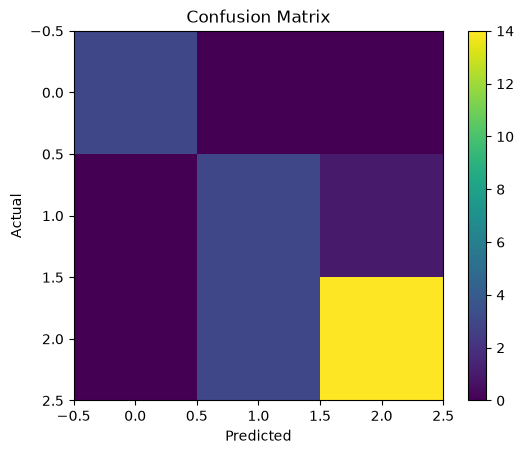

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         3
         Low       0.50      0.75      0.60         4
      Medium       0.93      0.82      0.88        17

    accuracy                           0.83        24
   macro avg       0.81      0.86      0.83        24
weighted avg       0.87      0.83      0.84        24



## 9. Feature importance

Feature importance shows which variables the Decision Tree relied on most while making its predictions.

In [ ]:
importance = model.feature_importances_

print(importance)

[0.         0.14461592 0.07314765 0.52490878 0.07711422 0.
 0.09113387 0.06894533 0.02013423]


In [ ]:
print(X.columns[3])

dropout_rate


**Observations** - We can see that dropout rate was the most influential feature. This means Decision Tree relied mainly on dropout rate while making its predictions. But It doesn't mean that dropout rate alone causes instructor effectiveness.

## 10.  Answers of Mandatory Analysis Questions

**1. Which features most influenced instructor effectiveness, and why?**

 Dropout rate is most influential in rating instuctor effectiveness, Lower dropout rate means higher instructor effectiveness.

**2. Which variables could be misleading or confounded?**

Course difficulty and Student feedback are some variables which could mislead or confound instructor efficiency

**3. How could the model fail in real-world usage?**

This model could fail on new dataset, large dataset, missing datasets or many other influential variables which we dont have data of.

**4. What additional data would improve the model?**

Student Attendance, Course difficulty, Student feedback and instrouctor experiance are some variables which could make this model more accurate.

**5. Should this model be used for instructor performance evaluation?**

 No this model shouldn't be used for instructor performance in real world as many factors like student attention, mislead feedbacks or other various variables which we don't have data of can also affect intructor effectiveness.

## Conclusion

The analysis was used to estimate instructor effectiveness using learner outcomes, engagement, and feedback data. Instructors were grouped into Low, Medium, and High effectiveness categories, and a Decision Tree was used to predict these categories.
